# Embryo Size Prediction & Hatching Detection
Load the saved 7-slice data from `data/`, run the full analysis pipeline on
every case, display detailed result panels for selected examples, then save a
`results.csv` summary to `data/`.

**Pipeline:**
```
raw 7 slices
    └─ VolumeBuilder  → dense 3-D volume (linear z-interpolation)
         └─ Segmentor → binary mask (Otsu + hole-fill)
              └─ EllipsoidFitter  → center, semi-axes, diameter, volume
                   └─ HatchingDetector → protrusion voxel count + flag
```

In [10]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd()))

import csv
import numpy as np
import matplotlib.pyplot as plt

from src.generator import BlastocystGenerator
from src.pipeline  import EmbryoPipeline
from src.visualisation import Visualiser

gen      = BlastocystGenerator()
pipeline = EmbryoPipeline(voxel_um=4.0, target_slices=56)
viz      = Visualiser()

## Configuration

In [11]:
DATA_DIR = "data"   # where 01_generate_test_data.ipynb saved the cases

# Indices of cases to show as detailed example panels (0-9)
EXAMPLE_INDICES = [0, 2, 5, 7]   # centred smooth, strong offcentre, hatching centred, hatching strong off

## Load data

In [12]:
batch = BlastocystGenerator.load_batch(DATA_DIR)
print(f"Loaded {len(batch)} cases from '{DATA_DIR}/'")
for slices, meta in batch:
    print(f"  [{meta['case_id']:2d}] {meta['name']:<30}  shape={slices.shape}  gt_hatching={meta['hatching']}")

Loaded 10 cases from 'data/'
  [ 0] centred_smooth                  shape=(7, 64, 64)  gt_hatching=False
  [ 1] mild_offcentre                  shape=(7, 64, 64)  gt_hatching=False
  [ 2] strong_offcentre                shape=(7, 64, 64)  gt_hatching=False
  [ 3] noisy_centred                   shape=(7, 64, 64)  gt_hatching=False
  [ 4] noisy_offcentre                 shape=(7, 64, 64)  gt_hatching=False
  [ 5] hatching_centred                shape=(7, 64, 64)  gt_hatching=True
  [ 6] hatching_mild_off               shape=(7, 64, 64)  gt_hatching=True
  [ 7] hatching_strong_off             shape=(7, 64, 64)  gt_hatching=True
  [ 8] hatching_noisy                  shape=(7, 64, 64)  gt_hatching=True
  [ 9] hatching_noisy_offcentre        shape=(7, 64, 64)  gt_hatching=True


## Run prediction pipeline on all cases

In [13]:
results = []

for slices, meta in batch:
    out = pipeline.run(slices)
    ell  = out["ellipsoid"]
    hat  = out["hatching"]

    record = {
        "case_id":            meta["case_id"],
        "name":               meta["name"],
        "gt_hatching":        meta["hatching"],
        "pred_hatching":      hat["is_hatching"],
        "correct":            hat["is_hatching"] == meta["hatching"],
        "diameter_um":        round(ell["diameter_um"],    1) if ell else None,
        "volume_um3":         round(ell["volume_um3"],     0) if ell else None,
        "semi_a_um":          round(ell["semi_axes_um"][0],1) if ell else None,
        "semi_b_um":          round(ell["semi_axes_um"][1],1) if ell else None,
        "semi_c_um":          round(ell["semi_axes_um"][2],1) if ell else None,
        "protrusion_voxels":  hat["protrusion_voxels"],
        "protrusion_fraction":hat["protrusion_fraction"],
        # store pipeline outputs for visualisation
        "_interp":  out["interp_volume"],
        "_mask":    out["mask"],
        "_ell":     ell,
        "_hat":     hat,
        "_slices":  slices,
        "_meta":    meta,
    }
    results.append(record)
    status = "✓" if record["correct"] else "✗"
    print(f"  {status} [{meta['case_id']:2d}] {meta['name']:<30}  "
          f"diam={record['diameter_um']} µm  hatching={hat['is_hatching']}")

  ✓ [ 0] centred_smooth                  diam=154.6 µm  hatching=False
  ✓ [ 1] mild_offcentre                  diam=154.5 µm  hatching=False
  ✓ [ 2] strong_offcentre                diam=155.0 µm  hatching=False
  ✓ [ 3] noisy_centred                   diam=156.5 µm  hatching=False
  ✓ [ 4] noisy_offcentre                 diam=156.6 µm  hatching=False
  ✓ [ 5] hatching_centred                diam=177.4 µm  hatching=True
  ✓ [ 6] hatching_mild_off               diam=175.9 µm  hatching=True
  ✓ [ 7] hatching_strong_off             diam=162.8 µm  hatching=True
  ✓ [ 8] hatching_noisy                  diam=179.2 µm  hatching=True
  ✓ [ 9] hatching_noisy_offcentre        diam=169.1 µm  hatching=True


## Accuracy

In [14]:
n_correct = sum(r["correct"] for r in results)
print(f"Hatching detection accuracy: {n_correct}/{len(results)} = {100*n_correct/len(results):.0f} %")

Hatching detection accuracy: 10/10 = 100 %


## Example result panels

Detailed two-row panels showing raw slices (top), segmentation + ellipsoid
overlay (bottom), and a metrics text box (right).

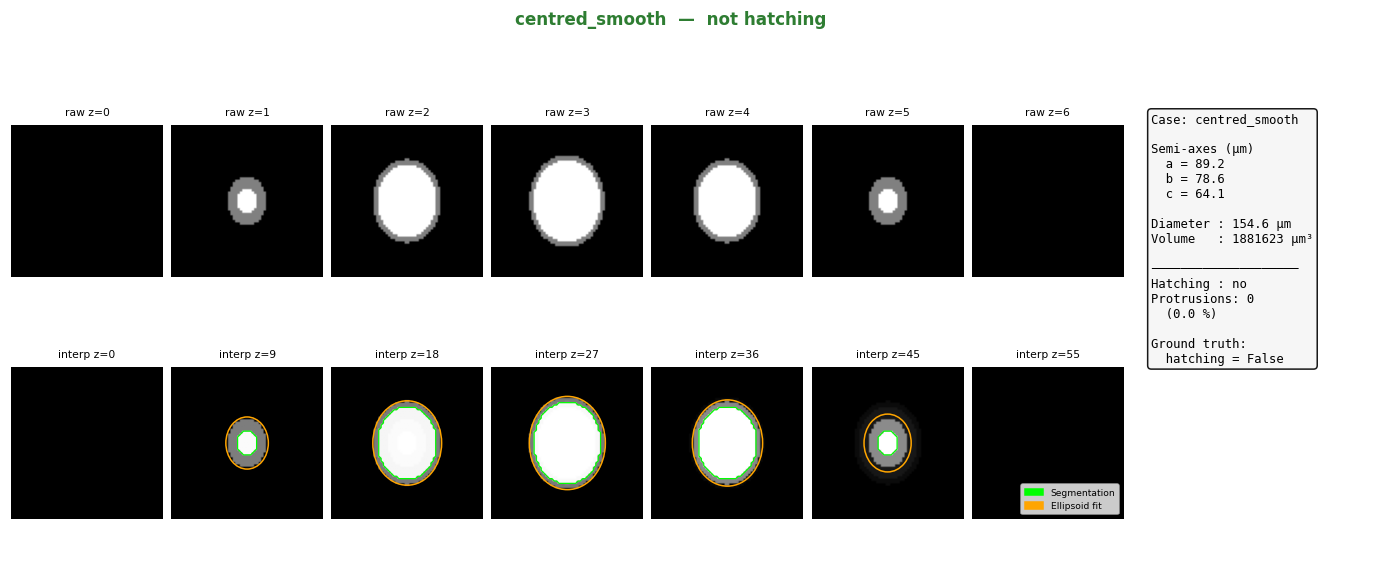

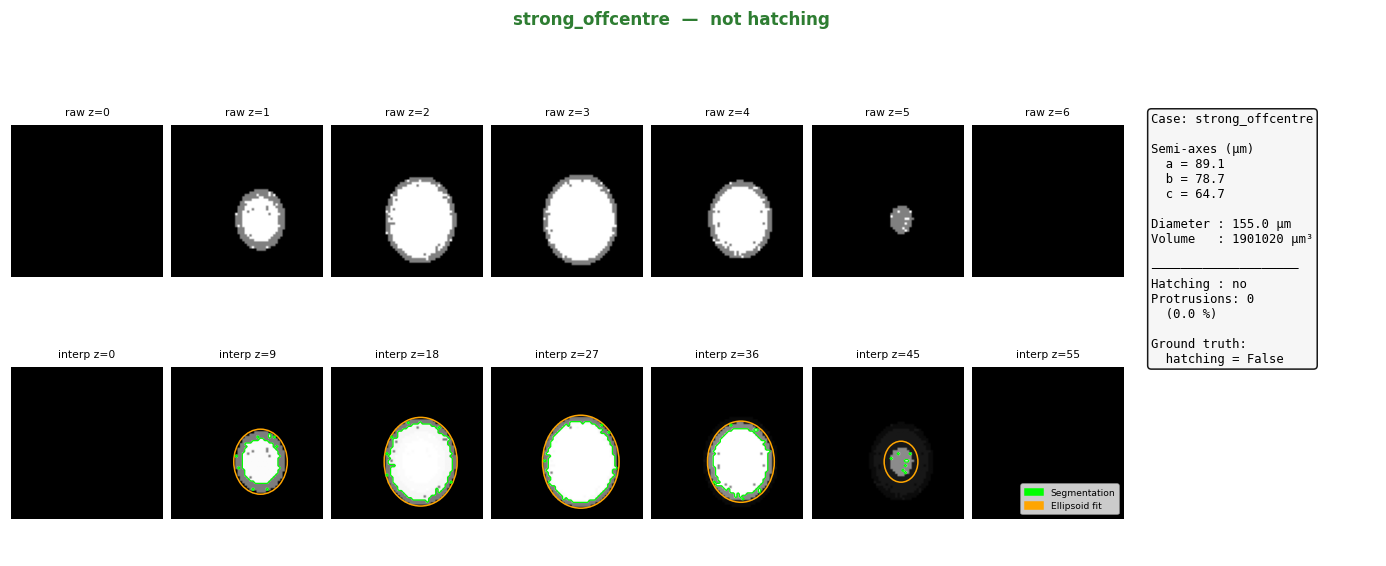

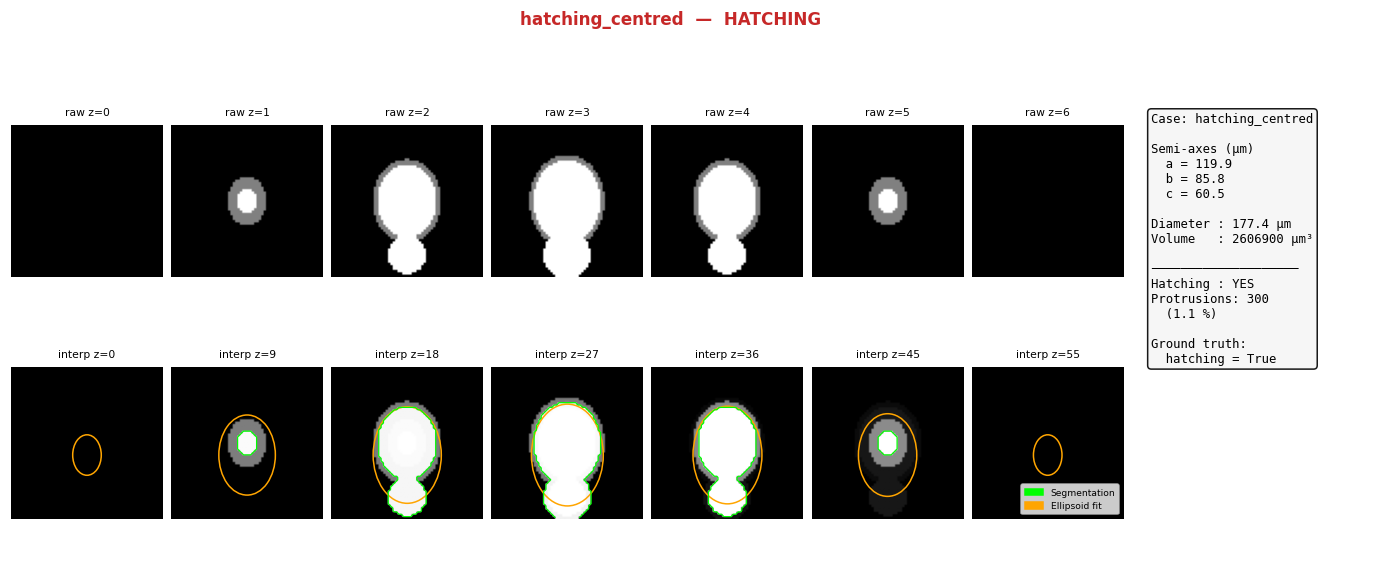

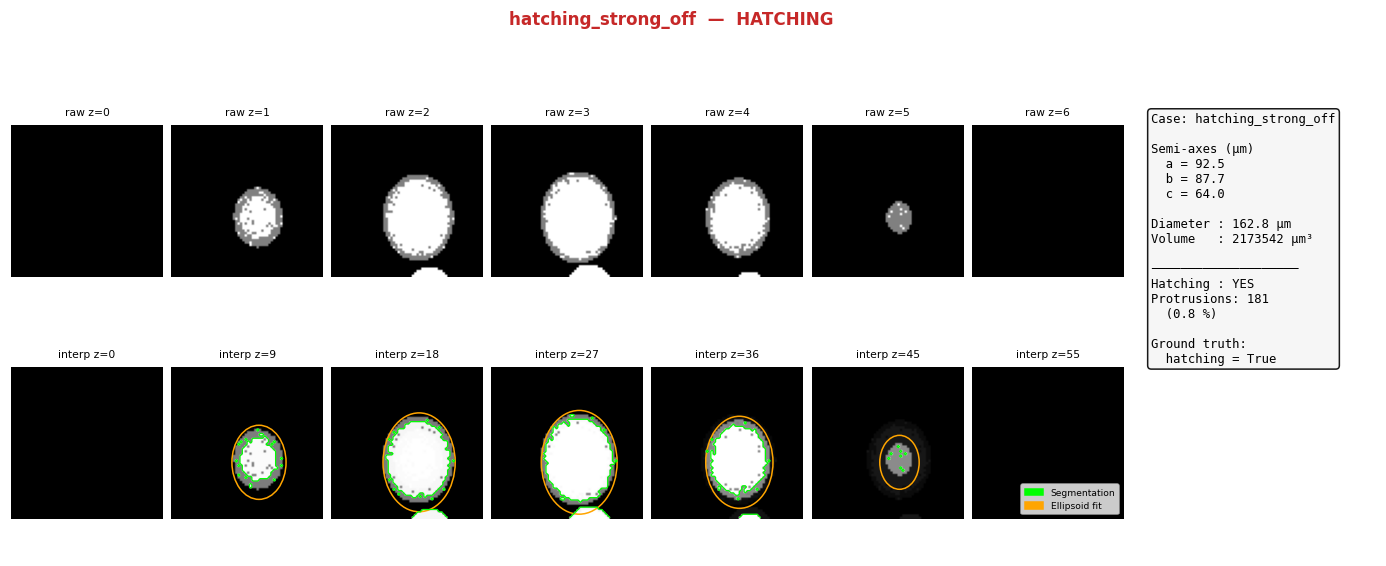

In [15]:
for idx in EXAMPLE_INDICES:
    r = results[idx]
    viz.plot_results_panel(
        raw_slices    = r["_slices"],
        interp_volume = r["_interp"],
        mask          = r["_mask"],
        ellipsoid     = r["_ell"],
        hatching      = r["_hat"],
        meta          = r["_meta"],
    )

## Batch diameter summary chart

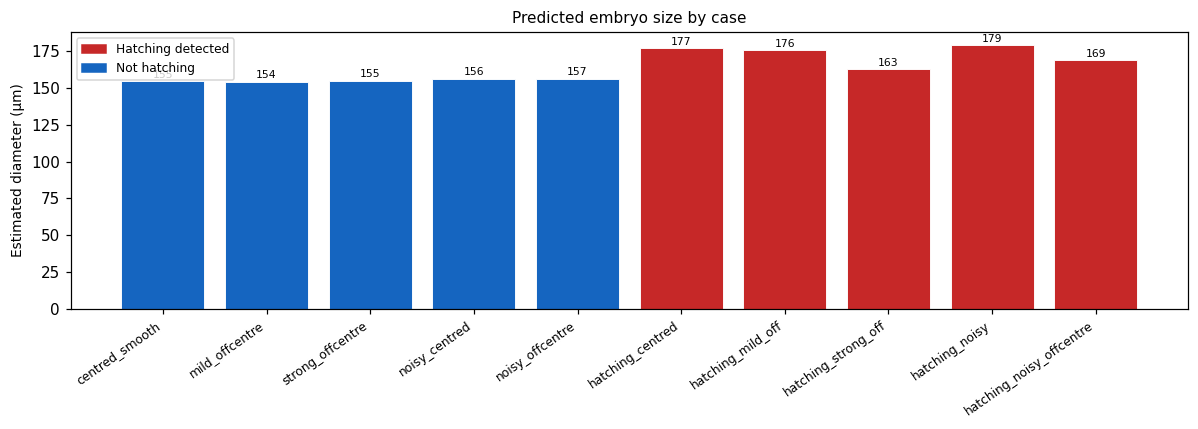

In [16]:
summary_records = [
    {"name": r["name"], "diameter_um": r["diameter_um"], "is_hatching": r["pred_hatching"]}
    for r in results
]
viz.plot_batch_summary(summary_records)

## Results table

In [17]:
header = ["case_id","name","gt_hatching","pred_hatching","correct",
          "diameter_um","volume_um3","semi_a_um","semi_b_um","semi_c_um",
          "protrusion_voxels","protrusion_fraction"]

col_w = [8, 28, 12, 14, 8, 12, 12, 10, 10, 10, 18, 20]

def fmt(v, w):
    return str(v if v is not None else "N/A").ljust(w)[:w]

print("  ".join(fmt(h, w) for h, w in zip(header, col_w)))
print("─" * sum(col_w + [2] * len(col_w)))
for r in results:
    row = [r[k] for k in header]
    print("  ".join(fmt(v, w) for v, w in zip(row, col_w)))

case_id   name                          gt_hatching   pred_hatching   correct   diameter_um   volume_um3    semi_a_um   semi_b_um   semi_c_um   protrusion_voxels   protrusion_fraction 
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
0         centred_smooth                False         False           True      154.6         1881623.0     89.2        78.6        64.1        0                   0.0                 
1         mild_offcentre                False         False           True      154.5         1880446.0     89.0        78.6        64.2        0                   0.0                 
2         strong_offcentre              False         False           True      155.0         1901020.0     89.1        78.7        64.7        0                   0.0                 
3         noisy_centred                 False         False           Tru

## Save results to `data/results.csv`

In [18]:
csv_path = f"{DATA_DIR}/results.csv"
save_keys = ["case_id","name","gt_hatching","pred_hatching","correct",
             "diameter_um","volume_um3","semi_a_um","semi_b_um","semi_c_um",
             "protrusion_voxels","protrusion_fraction"]

with open(csv_path, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=save_keys)
    writer.writeheader()
    for r in results:
        writer.writerow({k: r[k] for k in save_keys})

print(f"Saved → {csv_path}")

# Verify
with open(csv_path) as f:
    content = f.read()
print(content)

Saved → data/results.csv
case_id,name,gt_hatching,pred_hatching,correct,diameter_um,volume_um3,semi_a_um,semi_b_um,semi_c_um,protrusion_voxels,protrusion_fraction
0,centred_smooth,False,False,True,154.6,1881623.0,89.2,78.6,64.1,0,0.0
1,mild_offcentre,False,False,True,154.5,1880446.0,89.0,78.6,64.2,0,0.0
2,strong_offcentre,False,False,True,155.0,1901020.0,89.1,78.7,64.7,0,0.0
3,noisy_centred,False,False,True,156.5,1959165.0,89.2,80.1,65.4,0,0.0
4,noisy_offcentre,False,False,True,156.6,1961153.0,89.7,79.7,65.5,0,0.0
5,hatching_centred,True,True,True,177.4,2606900.0,119.9,85.8,60.5,300,0.0114
6,hatching_mild_off,True,True,True,175.9,2581444.0,116.0,86.0,61.8,354,0.0141
7,hatching_strong_off,True,True,True,162.8,2173542.0,92.5,87.7,64.0,181,0.0083
8,hatching_noisy,True,True,True,179.2,2691921.0,120.4,87.1,61.3,214,0.008
9,hatching_noisy_offcentre,True,True,True,169.1,2382430.0,103.1,87.7,62.9,299,0.013

